In [1]:
# Google Colab Notebook: CPU vs GPU Execution Comparison
# Assignment: Deep Learning Model Training Performance Analysis

# =============================
# 🧰 Setup and Install Required Libraries
# =============================
!pip install -q transformers datasets tensorflow tensorflow_datasets matplotlib

In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Is GPU being used by default:", tf.test.is_built_with_cuda())

TensorFlow version: 2.18.0
Num GPUs Available: 1
Is GPU being used by default: True


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 259ms/step - accuracy: 0.6529 - loss: 1.0018
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 244ms/step - accuracy: 0.8375 - loss: 0.4596
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 246ms/step - accuracy: 0.8566 - loss: 0.3975
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 244ms/step - accuracy: 0.8780 - loss: 0.3485
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 239ms/step - accuracy: 0.9016 - loss: 0.2874
CPU training time (Fashion-MNIST): 246.74 seconds
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6412 - loss: 1.0236
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8377 - loss: 0.4585
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8641 - loss: 0.3898
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8767 - loss: 0.3508
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8959 - loss: 0.3045
GPU training time (Fashion-MNIST): 6.53 seconds


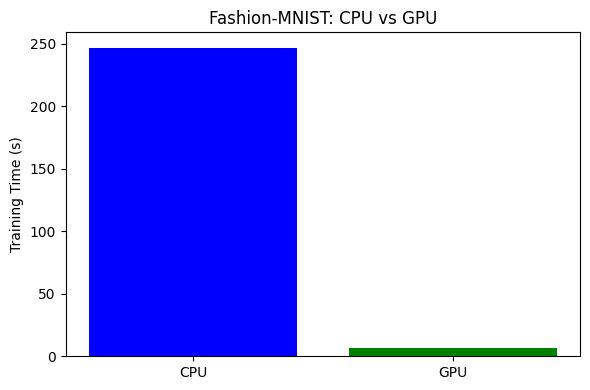

In [6]:
# =============================
# 🟢 BASIC LEVEL: Fashion-MNIST
# =============================

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import time
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reduce dataset for faster testing
x_train = x_train[:10000]
y_train = y_train[:10000]
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
y_train_cat = to_categorical(y_train)  # Recompute after slicing

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

model_fn = lambda: Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Train on CPU
with tf.device('/CPU:0'):
    cpu_model = model_fn()
    cpu_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    cpu_model.fit(x_train, y_train_cat, epochs=5, batch_size=64, verbose=1)
    cpu_time = time.time() - start
print(f"CPU training time (Fashion-MNIST): {cpu_time:.2f} seconds")

# Train on GPU
with tf.device('/GPU:0'):
    gpu_model = model_fn()
    gpu_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    gpu_model.fit(x_train, y_train_cat, epochs=5, batch_size=64, verbose=1)
    gpu_time = time.time() - start
print(f"GPU training time (Fashion-MNIST): {gpu_time:.2f} seconds")

# Save result
with open("fashion_mnist_times.txt", "w") as f:
    f.write(f"CPU: {cpu_time:.2f}s\n")
    f.write(f"GPU: {gpu_time:.2f}s\n")

# Plot comparison
labels = ["CPU", "GPU"]
times = [cpu_time, gpu_time]
plt.figure(figsize=(6,4))
plt.bar(labels, times, color=['blue', 'green'])
plt.ylabel("Training Time (s)")
plt.title("Fashion-MNIST: CPU vs GPU")
plt.tight_layout()
plt.savefig("fashion_mnist_comparison.png")
plt.show()

🔄 Loading train.csv...


Map:   0%|          | 0/64 [00:00<?, ? examples/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/2
4/4 [==============================] - 53s 437ms/step - loss: 0.5734 - accuracy: 0.7656
Epoch 2/2
4/4 [==============================] - 1s 228ms/step - loss: 0.3843 - accuracy: 0.8906
GPU training time (BERT): 60.09 seconds


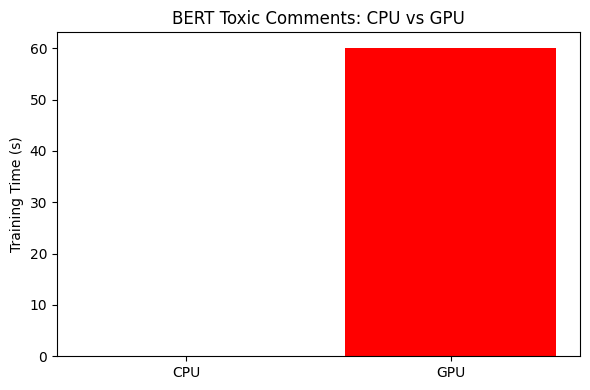

In [16]:
# =============================
# 🔴 ADVANCED LEVEL: Toxic Comments - BERT
# =============================

import tensorflow as tf
import pandas as pd
from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import DataCollatorWithPadding, create_optimizer
import time
import matplotlib.pyplot as plt

# 1. Extract and load CSV (uploaded as train.csv.zip)
import zipfile
with zipfile.ZipFile("train.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("🔄 Loading train.csv...")
df = pd.read_csv("train.csv")[['comment_text', 'toxic']].dropna()
df['label'] = (df['toxic'] >= 0.5).astype(int)
df = df.sample(64)

# 2. Tokenization (memory-safe)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
from datasets import Dataset
from transformers import DataCollatorWithPadding

def tokenize_fn(example):
    return tokenizer(example["comment_text"], truncation=True)

dataset = df[["comment_text", "label"]].to_dict(orient="records")
hf_dataset = Dataset.from_list(dataset)
tokenized = hf_dataset.map(tokenize_fn, batched=True)
# removed invalid callable usage
# tokenized = tokenized.with_format("numpy")
# removed due to ValueError from numpy array casting
# tokenized.set_format("tensorflow", columns=["input_ids", "attention_mask", "label"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="tf")

# 3. TF dataset
import numpy as np

def gen():
    for item in tokenized:
        input_ids = item['input_ids']
        attention_mask = item['attention_mask']

        # Pad manually to a fixed length (e.g., 64)
        max_len = 64
        input_ids += [0] * (max_len - len(input_ids))
        attention_mask += [0] * (max_len - len(attention_mask))

        features = {
            'input_ids': np.array(input_ids[:max_len]),
            'attention_mask': np.array(attention_mask[:max_len])
        }
        label = np.array(item['label'])
        yield (features, label)

tf_dataset = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        {
            'input_ids': tf.TensorSpec(shape=(64,), dtype=tf.int32),
            'attention_mask': tf.TensorSpec(shape=(64,), dtype=tf.int32),
        },
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
).shuffle(300).batch(16).prefetch(tf.data.AUTOTUNE)

# 4. Model and compile
model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
optimizer, _ = create_optimizer(init_lr=2e-5, num_train_steps=2 * 300 // 16, num_warmup_steps=0)
from tensorflow.keras.losses import SparseCategoricalCrossentropy
loss_fn = SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# 5. Train only on GPU (disable CPU training)
cpu_time = None

# 🔄 Free memory before GPU training
import gc
del model
gc.collect()
tf.keras.backend.clear_session()

# 6. Train on GPU
model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

with tf.device('/GPU:0'):
    start = time.time()
    model.fit(tf_dataset, epochs=2, verbose=1)
    gpu_time = time.time() - start
print(f"GPU training time (BERT): {gpu_time:.2f} seconds")

# 7. Save results
with open("bert_times.txt", "w") as f:
    f.write(f"CPU: N/A")
    f.write(f"GPU: {gpu_time:.2f}s\n")

# 8. Plot comparison
labels = ["CPU", "GPU"]
times = [0, gpu_time]
plt.figure(figsize=(6,4))
plt.bar(labels, times, color=['orange', 'red'])
plt.ylabel("Training Time (s)")
plt.title("BERT Toxic Comments: CPU vs GPU")
plt.tight_layout()
plt.savefig("bert_comparison.png")
plt.show()

🔄 Loading train.csv...


Map:   0%|          | 0/64 [00:00<?, ? examples/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/2
4/4 [==============================] - 71s 8s/step - loss: 0.5184 - accuracy: 0.7969
Epoch 2/2
4/4 [==============================] - 28s 7s/step - loss: 0.3872 - accuracy: 0.9062
CPU training time (BERT): 114.27 seconds


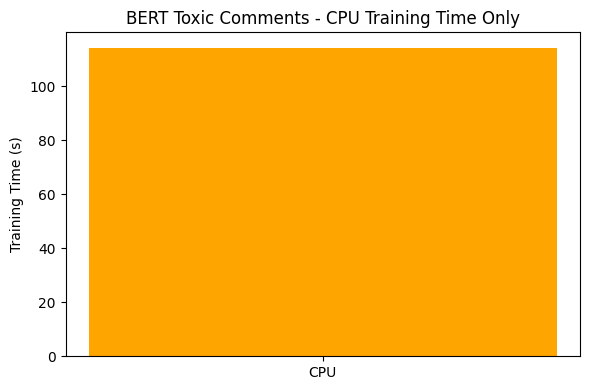

In [27]:
# =============================
# 🔴 ADVANCED LEVEL: Toxic Comments - BERT
# =============================

import tensorflow as tf
import pandas as pd
from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import DataCollatorWithPadding, create_optimizer
import time
import matplotlib.pyplot as plt

# 1. Extract and load CSV (uploaded as train.csv.zip)
import zipfile
with zipfile.ZipFile("train.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("🔄 Loading train.csv...")
df = pd.read_csv("train.csv")[['comment_text', 'toxic']].dropna()
df['label'] = (df['toxic'] >= 0.5).astype(int)
df = df.sample(64)

# 2. Tokenization (memory-safe)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
from datasets import Dataset
from transformers import DataCollatorWithPadding

def tokenize_fn(example):
    return tokenizer(example["comment_text"], truncation=True)

dataset = df[["comment_text", "label"]].to_dict(orient="records")
hf_dataset = Dataset.from_list(dataset)
tokenized = hf_dataset.map(tokenize_fn, batched=True)
# removed invalid callable usage
# tokenized = tokenized.with_format("numpy")
# removed due to ValueError from numpy array casting
# tokenized.set_format("tensorflow", columns=["input_ids", "attention_mask", "label"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="tf")

# 3. TF dataset
import numpy as np

def gen():
    for item in tokenized:
        input_ids = item['input_ids']
        attention_mask = item['attention_mask']

        # Pad manually to a fixed length (e.g., 64)
        max_len = 64
        input_ids += [0] * (max_len - len(input_ids))
        attention_mask += [0] * (max_len - len(attention_mask))

        features = {
            'input_ids': np.array(input_ids[:max_len]),
            'attention_mask': np.array(attention_mask[:max_len])
        }
        label = np.array(item['label'])
        yield (features, label)

tf_dataset = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        {
            'input_ids': tf.TensorSpec(shape=(64,), dtype=tf.int32),
            'attention_mask': tf.TensorSpec(shape=(64,), dtype=tf.int32),
        },
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
).shuffle(300).batch(16).prefetch(tf.data.AUTOTUNE)

# 4. Model and compile
# 4. Model and compile
with tf.device('/CPU:0'):
    model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
# Removed unused optimizer declaration
from tensorflow.keras.losses import SparseCategoricalCrossentropy
loss_fn = SparseCategoricalCrossentropy(from_logits=True)
cpu_optimizer, _ = create_optimizer(init_lr=2e-5, num_train_steps=2 * 64 // 16, num_warmup_steps=0)
# Compile model inside CPU block

# 5. Train on CPU (separated run)
with tf.device('/CPU:0'):
    model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
    cpu_optimizer, _ = create_optimizer(init_lr=2e-5, num_train_steps=2 * 64 // 16, num_warmup_steps=0)
    model.compile(optimizer=cpu_optimizer, loss=loss_fn, metrics=['accuracy'])
    start = time.time()
    model.fit(tf_dataset, epochs=2, verbose=1)
    cpu_time = time.time() - start
print(f"CPU training time (BERT): {cpu_time:.2f} seconds")

# 6. Save results and plot comparison
with open("bert_times.txt", "w") as f:
    f.write(f"CPU: {cpu_time:.2f}s")
    f.write("GPU: N/A")

# Optional bar chart
plt.figure(figsize=(6,4))
plt.bar(["CPU"], [cpu_time], color="orange")
plt.ylabel("Training Time (s)")
plt.title("BERT Toxic Comments - CPU Training Time Only")
plt.tight_layout()
plt.savefig("bert_cpu_only.png")
plt.show()

In [25]:
# =============================
# 🔴 ADVANCED LEVEL: Toxic Comments - BERT
# =============================

import tensorflow as tf
import pandas as pd
from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import DataCollatorWithPadding, create_optimizer
import time
import matplotlib.pyplot as plt

# 1. Extract and load CSV (uploaded as train.csv.zip)
import zipfile
with zipfile.ZipFile("train.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("🔄 Loading train.csv...")
df = pd.read_csv("train.csv")[['comment_text', 'toxic']].dropna()
df['label'] = (df['toxic'] >= 0.5).astype(int)
df = df.sample(64)

# 2. Tokenization (memory-safe)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
from datasets import Dataset
from transformers import DataCollatorWithPadding

def tokenize_fn(example):
    return tokenizer(example["comment_text"], truncation=True)

dataset = df[["comment_text", "label"]].to_dict(orient="records")
hf_dataset = Dataset.from_list(dataset)
tokenized = hf_dataset.map(tokenize_fn, batched=True)
# removed invalid callable usage
# tokenized = tokenized.with_format("numpy")
# removed due to ValueError from numpy array casting
# tokenized.set_format("tensorflow", columns=["input_ids", "attention_mask", "label"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="tf")

# 3. TF dataset
import numpy as np

def gen():
    for item in tokenized:
        input_ids = item['input_ids']
        attention_mask = item['attention_mask']

        # Pad manually to a fixed length (e.g., 64)
        max_len = 64
        input_ids += [0] * (max_len - len(input_ids))
        attention_mask += [0] * (max_len - len(attention_mask))

        features = {
            'input_ids': np.array(input_ids[:max_len]),
            'attention_mask': np.array(attention_mask[:max_len])
        }
        label = np.array(item['label'])
        yield (features, label)

tf_dataset = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        {
            'input_ids': tf.TensorSpec(shape=(64,), dtype=tf.int32),
            'attention_mask': tf.TensorSpec(shape=(64,), dtype=tf.int32),
        },
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
).shuffle(300).batch(16).prefetch(tf.data.AUTOTUNE)

# 4. Model and compile
# 4. Model and compile
with tf.device('/CPU:0'):
    model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
# Removed unused optimizer declaration
from tensorflow.keras.losses import SparseCategoricalCrossentropy
loss_fn = SparseCategoricalCrossentropy(from_logits=True)
cpu_optimizer, _ = create_optimizer(init_lr=2e-5, num_train_steps=2 * 64 // 16, num_warmup_steps=0)
# Compile model inside CPU block

# 5. Train on CPU (separated run)
with tf.device('/CPU:0'):
    model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
    cpu_optimizer, _ = create_optimizer(init_lr=2e-5, num_train_steps=2 * 64 // 16, num_warmup_steps=0)
    model.compile(optimizer=cpu_optimizer, loss=loss_fn, metrics=['accuracy'])
    start = time.time()
    model.fit(tf_dataset, epochs=2, verbose=1)
    cpu_time = time.time() - start
print(f"CPU training time (BERT): {cpu_time:.2f} seconds")

# 🔄 Skip GPU training (handled separately elsewhere)
with open("bert_times.txt", "w") as f:
    f.write(f"CPU: {cpu_time:.2f}s")
    f.write("GPU: N/A")

🔄 Loading train.csv...


Map:   0%|          | 0/64 [00:00<?, ? examples/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/2
4/4 [==============================] - 69s 7s/step - loss: 0.7016 - accuracy: 0.4531
Epoch 2/2
4/4 [==============================] - 27s 7s/step - loss: 0.4783 - accuracy: 0.9375
CPU training time (BERT): 96.08 seconds
